In [1]:
# Install required Python libraries for data analysis and machine learning
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn -q

# Import libraries
import yfinance as yf              # API to download stock market data
import pandas as pd               # Data handling (DataFrames)
import numpy as np                # Numerical computations
import matplotlib.pyplot as plt   # Plotting graphs
import seaborn as sns             # Advanced visualization
import warnings                   # To control warning messages


warnings.filterwarnings('ignore') # Ignore warnings to keep output clean

ticker = yf.Ticker('^NSEI') # Create a ticker object for NIFTY 50 index (^NSEI)

# Download historical stock data from Jan 1, 2019 to Dec 31, 2024
# This includes OHLCV data (Open, High, Low, Close, Volume)
df = ticker.history(start='2019-01-01', end='2024-12-31')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

df.index = pd.to_datetime(df.index)  # Convert index to datetime format for proper time-series handling

# Print dataset shape (rows, columns)
# Helps understand how much data we have
print(f"Dataset shape: {df.shape}")

# Print date range of the dataset
# Ensures correct time period is loaded
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")

# Display first 10 rows of the dataset
# Used to verify data correctness and structure
df.head(10)

Dataset shape: (1477, 5)
Date range: 2019-01-02 to 2024-12-30


,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02 00:00:00+05:30,10868.849609,10895.349609,10735.049805,10792.500000,309700
2019-01-03 00:00:00+05:30,10796.799805,10814.049805,10661.250000,10672.250000,286200
2019-01-04 00:00:00+05:30,10699.700195,10741.049805,10628.650391,10727.349609,296600
2019-01-07 00:00:00+05:30,10804.849609,10835.950195,10750.150391,10771.799805,269400
2019-01-08 00:00:00+05:30,10786.250000,10818.450195,10733.250000,10802.150391,277700
2019-01-09 00:00:00+05:30,10862.400391,10870.400391,10749.400391,10855.150391,333000
2019-01-10 00:00:00+05:30,10859.349609,10859.349609,10801.799805,10821.599609,254400
2019-01-11 00:00:00+05:30,10834.750000,10850.150391,10739.400391,10794.950195,260800
2019-01-14 00:00:00+05:30,10807.000000,10808.000000,10692.349609,10737.599609,298800


In [10]:
# Data Preprocessing

# 2a. Check for missing values in each column
# This helps identify incomplete data which can affect model performance
print("=== Missing Values ===")
print(df.isnull().sum())

# 2b. Check for duplicate rows
# Duplicate data can bias the model and distort patterns
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# 2c. Drop rows with missing values (NaN)
# Ensures clean dataset for analysis and model training
df.dropna(inplace=True)

# 2d. Display data types of each column
# Helps verify correct format (e.g., float for prices, int for volume)
print("\n=== Dataset Info ===")
print(df.dtypes)

# 2e. Display summary statistics
# Includes mean, standard deviation, min, max, quartiles
# Helps understand data distribution and detect anomalies
print("\n=== Summary Statistics ===")
df.describe().round(2)

=== Missing Values ===
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate rows: 0

=== Dataset Info ===
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

=== Summary Statistics ===


,Open,High,Low,Close,Volume
count,1477.00,1477.00,1477.00,1477.00,1477.00
mean,16383.65,16461.70,16278.22,16372.56,402483.89
std,4411.15,4419.36,4402.78,4411.44,207804.80
min,7735.15,8036.95,7511.10,7610.25,0.00
25%,11928.80,11969.25,11850.25,11914.20,257700.00
50%,16947.50,17091.00,16828.35,16953.95,333600.00
75%,18908.15,19011.25,18837.85,18857.25,514800.00
max,26248.25,26277.35,26151.40,26216.05,1811000.00


In [11]:
# Feature Engineering

# Moving Averages (Trend Indicators)
# MA20 → short-term trend (last 20 days)
# MA50 → medium-term trend (last 50 days)
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# RSI (Relative Strength Index - Momentum Indicator)
# Measures speed and strength of price movement (range: 0–100)
# >70 → overbought (sell signal), <30 → oversold (buy signal)
def compute_rsi(series, period=14):
    delta = series.diff()                          # price change
    gain  = delta.clip(lower=0).rolling(period).mean()   # positive changes
    loss  = (-delta.clip(upper=0)).rolling(period).mean() # negative changes
    rs    = gain / loss                            # relative strength
    return 100 - (100 / (1 + rs))                  # RSI formula

df['RSI'] = compute_rsi(df['Close'])

# MACD (Trend + Momentum Indicator)
# Difference between short-term EMA (12) and long-term EMA (26)
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26                         # MACD line
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()  # signal line

# Bollinger Bands (Volatility Indicator)
# Shows price range using mean ± 2 standard deviations
rolling = df['Close'].rolling(window=20)

df['BB_upper'] = rolling.mean() + 2 * rolling.std()   # upper band
df['BB_lower'] = rolling.mean() - 2 * rolling.std()   # lower band

# Remove NaN values created due to rolling calculations
# (initial rows don't have enough data for window calculations)
df.dropna(inplace=True)

# Print updated dataset info
print(f"Features added. Final shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Show last 5 rows of important features
df[['Close','MA20','MA50','RSI','MACD','BB_upper','BB_lower']].tail(5)

Features added. Final shape: (1428, 12)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50', 'RSI', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower']


,Close,MA20,MA50,RSI,MACD,BB_upper,BB_lower
Date,,,,,,,
2024-12-23 00:00:00+05:30,23753.449219,24339.255078,24300.868047,32.759206,-82.033872,25018.555295,23659.954861
2024-12-24 00:00:00+05:30,23727.650391,24315.912598,24276.136055,32.011432,-111.759223,25046.318478,23585.506717
2024-12-26 00:00:00+05:30,23750.199219,24289.677539,24248.581055,23.932179,-131.975939,25062.733624,23516.621454
2024-12-27 00:00:00+05:30,23813.400391,24284.640039,24223.702070,26.893892,-141.269558,25069.226605,23500.053473
2024-12-30 00:00:00+05:30,23644.900391,24260.330078,24197.174062,25.404024,-160.382570,25093.568409,23427.091748


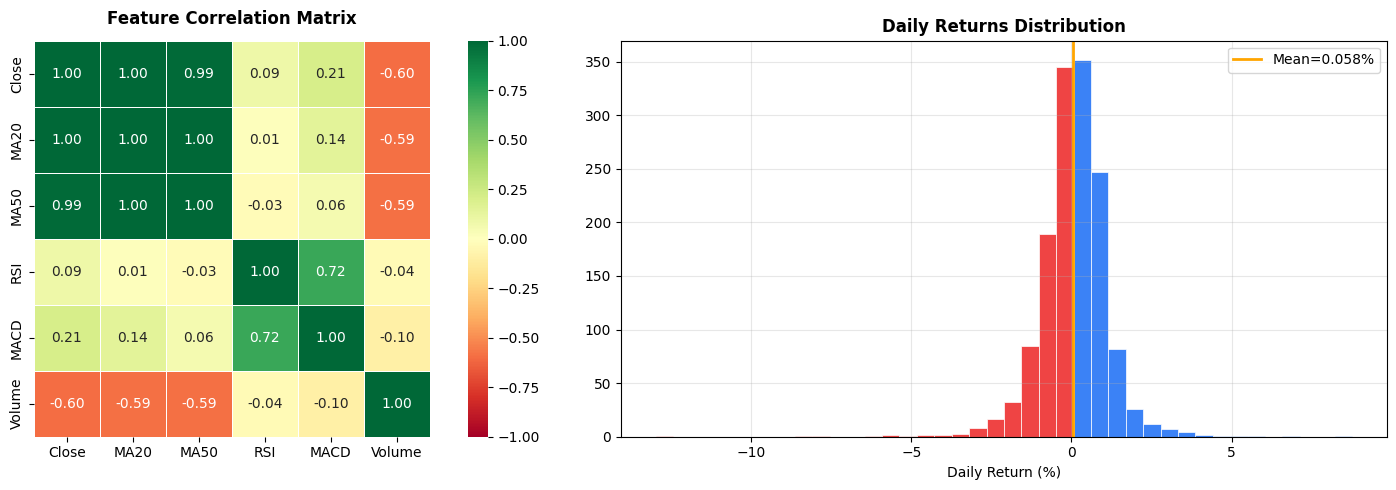

Skewness : -1.229
Kurtosis : 18.759
Std Dev  : 1.170%


In [12]:
# Exploratory Data Analysis (EDA)

# Create a figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 4a. Correlation Heatmap
# Shows relationship between features (how strongly they are related)
cols = ['Close','MA20','MA50','RSI','MACD','Volume']
corr = df[cols].corr()   # compute correlation matrix
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
           vmin=-1, vmax=1, ax=axes[0],
           linewidths=0.5, square=True)

axes[0].set_title('Feature Correlation Matrix', fontweight='bold', pad=12)


# 4b. Daily Returns Distribution (Histogram)
# Calculates percentage change in closing price
daily_ret = df['Close'].pct_change() * 100

# Plot histogram of returns
n, bins, patches = axes[1].hist(daily_ret.dropna(), bins=40,edgecolor='white', linewidth=0.5)

# Color negative returns red and positive returns blue
for b, p in zip(bins, patches):
    p.set_facecolor('#ef4444' if b < 0 else '#3b82f6')

# Plot mean return line
axes[1].axvline(daily_ret.mean(), color='orange', lw=2,label=f'Mean={daily_ret.mean():.3f}%')
axes[1].set_title('Daily Returns Distribution', fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

# Print statistical properties of returns
print(f"Skewness : {daily_ret.skew():.3f}")   # asymmetry
print(f"Kurtosis : {daily_ret.kurtosis():.3f}")  # fat tails
print(f"Std Dev  : {daily_ret.std():.3f}%")   # volatility

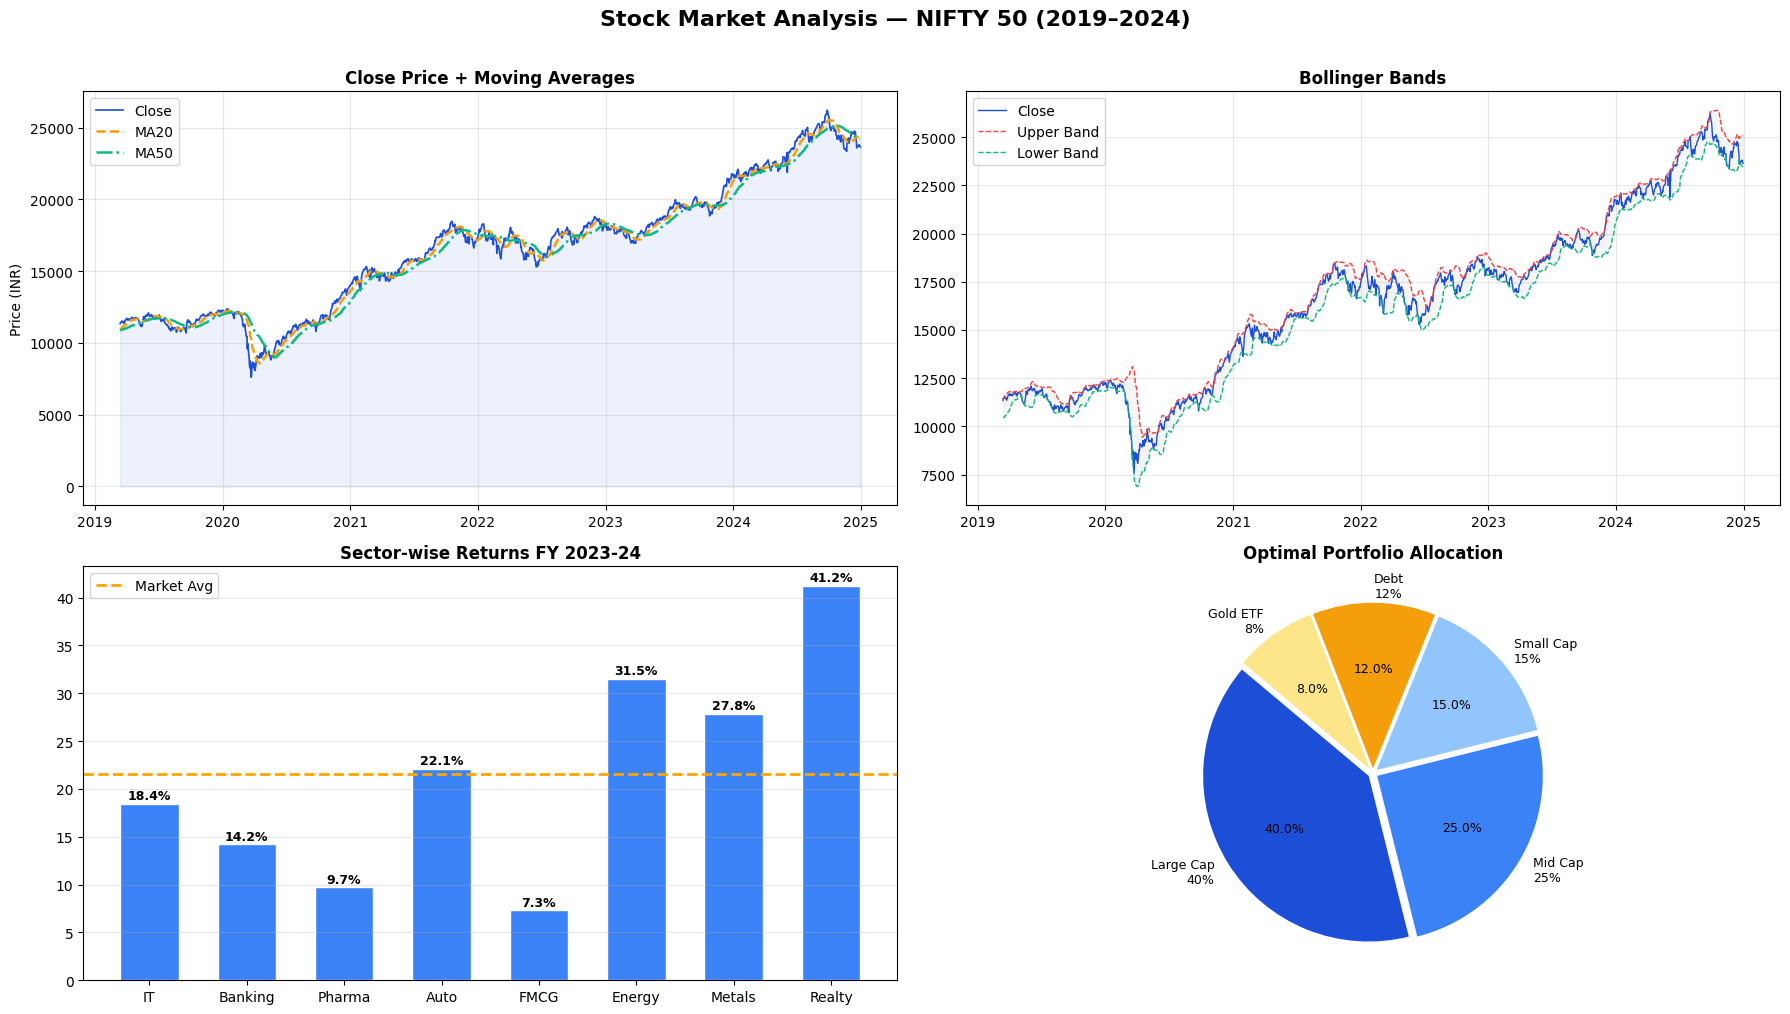

In [13]:
# Data Visualization (4 Charts)
fig, axes = plt.subplots(2, 2, figsize=(18, 10)) # Create 2x2 subplot layout

# Add overall title
plt.suptitle('Stock Market Analysis — NIFTY 50 (2019–2024)',
             fontsize=16, fontweight='bold', y=1.01)

# Chart 1: Close Price + Moving Averages (Trend Analysis)
axes[0,0].plot(df.index, df['Close'], color='#1d4ed8', lw=1.2, label='Close')
axes[0,0].plot(df.index, df['MA20'],  color='#f59e0b', lw=1.8, ls='--', label='MA20')
axes[0,0].plot(df.index, df['MA50'],  color='#10b981', lw=1.8, ls='-.', label='MA50')

# Fill area under price curve for visualization clarity
axes[0,0].fill_between(df.index, df['Close'], alpha=0.08, color='#1d4ed8')
axes[0,0].set_title('Close Price + Moving Averages', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)
axes[0,0].set_ylabel('Price (INR)')

# Chart 2: Bollinger Bands (Volatility Analysis)
axes[0,1].plot(df.index, df['Close'],    color='#1d4ed8', lw=1, label='Close')
axes[0,1].plot(df.index, df['BB_upper'], color='#ef4444', lw=1, ls='--', label='Upper Band')
axes[0,1].plot(df.index, df['BB_lower'], color='#10b981', lw=1, ls='--', label='Lower Band')

# Fill band region (volatility range)
axes[0,1].fill_between(df.index, df['BB_upper'], df['BB_lower'], alpha=0.08, color='gray')
axes[0,1].set_title('Bollinger Bands', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Chart 3: Sector-wise Returns (Performance Comparison)
sectors = ['IT','Banking','Pharma','Auto','FMCG','Energy','Metals','Realty']
ret_vals = [18.4, 14.2, 9.7, 22.1, 7.3, 31.5, 27.8, 41.2]
bars = axes[1,0].bar(sectors, ret_vals, color='#3b82f6', edgecolor='white', width=0.6)

# Annotate each bar with percentage value
for bar, val in zip(bars, ret_vals):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,f'{val}%', ha='center', fontsize=9, fontweight='bold')

# Plot average market return line
axes[1,0].axhline(sum(ret_vals)/len(ret_vals), color='orange', ls='--', lw=2, label='Market Avg')
axes[1,0].set_title('Sector-wise Returns FY 2023-24', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3, axis='y')

# Chart 4: Portfolio Allocation (Investment Strategy)
labels = ['Large Cap\n40%','Mid Cap\n25%','Small Cap\n15%','Debt\n12%','Gold ETF\n8%']
sizes  = [40, 25, 15, 12, 8]
colors = ['#1d4ed8','#3b82f6','#93c5fd','#f59e0b','#fde68a']
axes[1,1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',explode=[0.03]*5, startangle=140, textprops={'fontsize':9})
axes[1,1].set_title('Optimal Portfolio Allocation', fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [16]:
# LSTM Model for Time-Series Prediction
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# 6a. Normalize Close price to [0,1]
# Reason: neural networks train faster and more stably on scaled data
scaler    = MinMaxScaler(feature_range=(0, 1))
close_arr = df[['Close']].values
scaled    = scaler.fit_transform(close_arr)

# 6b. Create sliding window sequences (lookback = 60 days)
# Each input X = past 60 days, target y = next day price
SEQ_LEN = 60
X, y = [], []
for i in range(SEQ_LEN, len(scaled)):
    X.append(scaled[i-SEQ_LEN:i, 0])   # last 60 days
    y.append(scaled[i, 0])             # next day value

X, y = np.array(X), np.array(y)

# Reshape into 3D format required by LSTM: (samples, time_steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# 6c. Chronological train-test split (no shuffling!)
# Reason: time-series must preserve order
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# 6d. Build LSTM model
model = Sequential([
    # First LSTM layer (captures long-term patterns)
    LSTM(128, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),   # prevents overfitting
    # Second LSTM layer (refines learned patterns)
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    # Fully connected layers (final prediction)
    Dense(32, activation='relu'),
    Dense(1)   # output = predicted price
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')
# Show architecture
model.summary()

# 6e. Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,   # 10% data for validation
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

Train: (1094, 60, 1)  |  Test: (274, 60, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 0.0372 - val_loss: 0.0020
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0040 - val_loss: 3.6622e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0018 - val_loss: 3.0956e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - loss: 0.0017 - val_loss: 3.2390e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.0015 - val_loss: 3.2616e-04
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0016 - val_loss: 7.7850e-04
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0015 - val_loss: 8.2086e-04
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - loss: 0.0013 - val_loss: 3.1479e-04
Epoch 12/50
31/31 ━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
MODEL PERFORMANCE RESULTS
  RMSE : 457.95 INR
  MAE  : 383.21 INR
  MAPE : 1.62%
  R² Score : 0.9063
  Directional Acc. : 52.0%


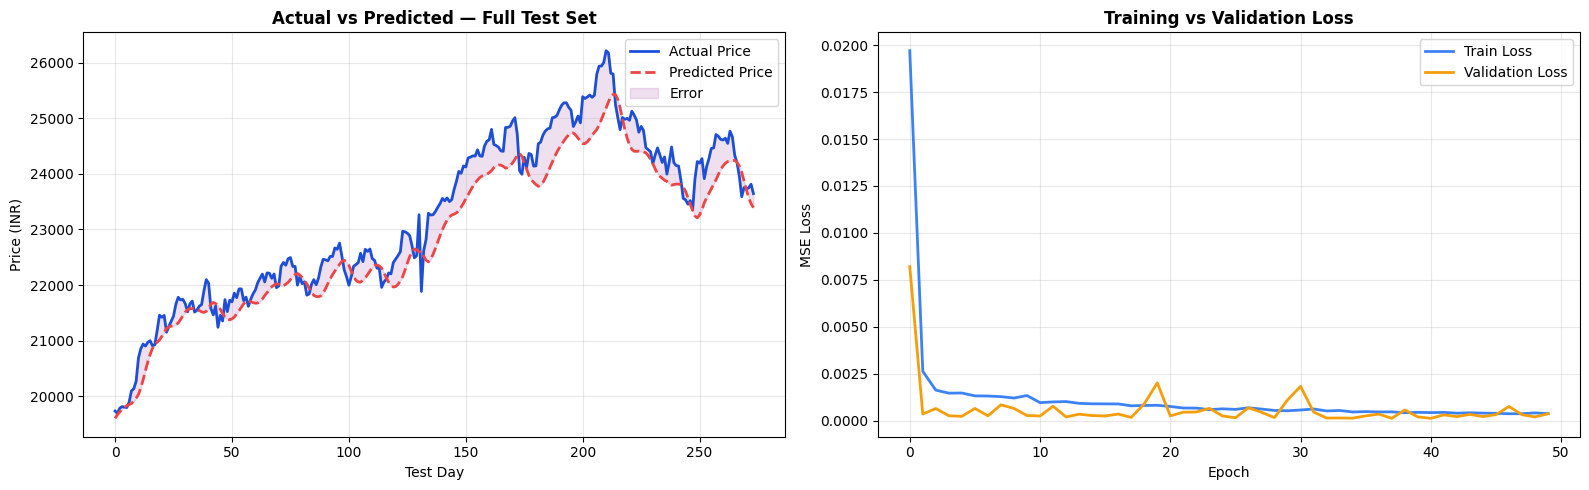

In [15]:
# Results & Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 7a. Make predictions on test data
pred_scaled = model.predict(X_test) # Model outputs scaled values → convert back to original INR scale

# Convert predictions back to actual price range
pred_price   = scaler.inverse_transform(pred_scaled)

# Convert actual test values back to original scale
actual_price = scaler.inverse_transform(y_test.reshape(-1, 1))

# 7b. Performance Metrics
rmse = np.sqrt(mean_squared_error(actual_price, pred_price)) # RMSE → penalizes large errors (sensitive to outliers)
mae  = mean_absolute_error(actual_price, pred_price) # MAE → average absolute error (more interpretable)
mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100 # MAPE → percentage error (scale-independent)
r2   = r2_score(actual_price, pred_price) # R² → how well model explains variance

# Directional Accuracy → how often model predicts correct up/down movement
actual_dir = np.sign(np.diff(actual_price.flatten()))
pred_dir   = np.sign(np.diff(pred_price.flatten()))
dir_acc    = np.mean(actual_dir == pred_dir) * 100

# Print results
print("="*45)
print("MODEL PERFORMANCE RESULTS")
print("="*45)
print(f"  RMSE : {rmse:.2f} INR")
print(f"  MAE  : {mae:.2f} INR")
print(f"  MAPE : {mape:.2f}%")
print(f"  R² Score : {r2:.4f}")
print(f"  Directional Acc. : {dir_acc:.1f}%")
print("="*45)


# 7c. Visualization of results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Actual vs Predicted Prices
axes[0].plot(actual_price, color='#1d4ed8', lw=2, label='Actual Price')
axes[0].plot(pred_price,   color='#ef4444', lw=2, ls='--', label='Predicted Price')

# Highlight prediction error
axes[0].fill_between(range(len(actual_price)), actual_price.flatten(), pred_price.flatten(), alpha=0.12, color='purple', label='Error')
axes[0].set_title('Actual vs Predicted — Full Test Set', fontweight='bold')
axes[0].set_xlabel('Test Day')
axes[0].set_ylabel('Price (INR)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Training vs Validation Loss
axes[1].plot(history.history['loss'],     color='#3b82f6', lw=2, label='Train Loss')
axes[1].plot(history.history['val_loss'], color='#f59e0b', lw=2, label='Validation Loss')
axes[1].set_title('Training vs Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Display plots
plt.tight_layout()
plt.show()